In [9]:
# Importing necessary libraries
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
# Data Transformation during loading the dataset of images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Downloading the data
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Forming dataloaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=1000)

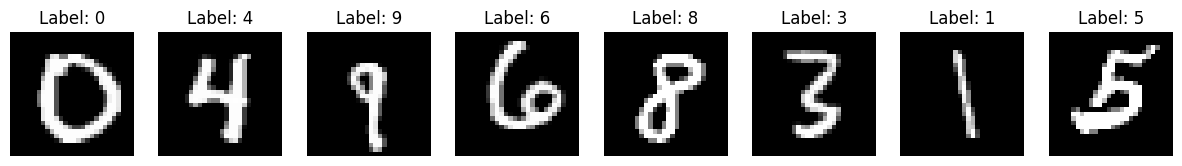

In [11]:
# Visualization
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')  # grayscale
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')

plt.show()

---

In [12]:
# Teacher Model → 2 Hidden Layers
class TeacherMLP(nn.Module):
    def __init__(self, hidden1=512, hidden2=256):
        super().__init__()

        # Teacher Model Architecture
        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, hidden1),
            nn.ReLU(),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),

            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        return self.net(x)

In [13]:
teacher = TeacherMLP(hidden1=512, hidden2=256)
teacher

TeacherMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [14]:
# Training Pipeline for teacher model
def train_teacher(model: TeacherMLP, loader: DataLoader, epochs=5, lr=1e-3):

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.to(device)
    model.train() # Set the model in training mode.

    for ep in range(epochs):
        total_loss = 0

        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(features)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Teacher Epoch {ep+1}: Loss = {total_loss / len(loader):.4f}")

In [15]:
# Training Teacher Model
train_teacher(teacher, train_loader)

Teacher Epoch 1: Loss = 0.3058
Teacher Epoch 2: Loss = 0.1367
Teacher Epoch 3: Loss = 0.1050
Teacher Epoch 4: Loss = 0.0836
Teacher Epoch 5: Loss = 0.0711


---

In [16]:
# Student Model
class StudentMLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()

        # Student Model Architecture
        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, hidden),
            nn.ReLU(),

            nn.Linear(hidden, 10)
        )

    def forward(self, x):
        return self.net(x)

In [18]:
student = StudentMLP(hidden=128).to(device)
student

StudentMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [24]:
# Knowledge Distillation Training Pipeline

temperature = 2.0 # Soften the distribution of softmax probabilities for better visibility of classes other than actual class
alpha = 0.7 # Focusing more on mimicing the behavour of teacher model

cross_entropy_criterion = nn.CrossEntropyLoss()
kl_divergence_criterion = nn.KLDivLoss(reduction="batchmean")

optimizer = optim.Adam(student.parameters(), lr=1e-3)

def KnowledgeDistillation(student, teacher, loader, epochs=5):
    for epoch in range(epochs):
        student.train()
        total_loss = 0

        for features, labels in loader:
            optimizer.zero_grad()
            features, labels = features.to(device), labels.to(device)

            # Teacher outputs
            with torch.no_grad():
                teacher_logits = teacher(features)
                normalized_teacher_logits = torch.softmax(teacher_logits / temperature, dim=1)

            # Student outputs
            student_logits = student(features)
            normalized_student_logits = torch.log_softmax(student_logits / temperature, dim=1) # Why log_softmax

            # Losses
            loss_soft = kl_divergence_criterion(normalized_student_logits, normalized_teacher_logits) * (temperature**2) # Why temperature square
            loss_hard = cross_entropy_criterion(student_logits, labels)
            loss = alpha * loss_soft + (1 - alpha) * loss_hard

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Student Epoch {epoch+1}: Loss = {total_loss/len(loader):.4f}")

In [25]:
# Training Student Model
KnowledgeDistillation(student, teacher, train_loader, epochs=5)

Student Epoch 1: Loss = 0.3618
Student Epoch 2: Loss = 0.1975
Student Epoch 3: Loss = 0.1411
Student Epoch 4: Loss = 0.1168
Student Epoch 5: Loss = 0.1044


In [48]:
# Model Evaluation
def evaluate(model, loader, name="Model"):
    # Model transfer to evaluation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            logits = model(features)
            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    acc = correct / total * 100
    return acc

In [50]:
# Evaluate both Teacher and Student models
teacher_acc = evaluate(teacher, test_loader, "Teacher")
student_acc = evaluate(student, test_loader, "Teacher")

print(f"Teacher Accuracy: {teacher_acc:.2f}%")
print(f"Student Accuracy: {student_acc:.2f}%")

Teacher Accuracy: 97.74%
Student Accuracy: 97.17%


In [47]:
# Latency Reduction
import time

start_time = time.time()
teacher(train_data[0][0].to(device))
end_time = time.time()
teacher_execution_time = end_time - start_time
print(f"Teacher Execution Time: {teacher_execution_time:.2f} seconds")

start_time = time.time()
student(train_data[0][0].to(device))
end_time = time.time()
student_execution_time = end_time - start_time
print(f"Student Execution Time: {student_execution_time:.2f} seconds")

print(f"Latency reduced by {(teacher_execution_time - student_execution_time) / teacher_execution_time * 100}%")

Teacher Execution Time: 0.00 seconds
Student Execution Time: 0.00 seconds
Latency reduced by 2.4026820636990127%


In [52]:
# Performence Retention
print(f"Performance retianed by {student_acc * 100 / teacher_acc}%")

Performance retianed by 99.41682013505218%


---